# 밑바닥부터 GPT 모델 구현하기 목차
* [Chapter 1 LLM 구조 구현하기](#chapter1)
* [Chapter 2 층 정규화로 활성화 정규화하기](#chapter2)
* [Chapter 3 GELU 활성화 함수를 사용하는 피듸 포워드 네트워크 구현하기](#chapter3)
* [Chapter 4 쇼컷 연결 추가하기](#chapter4)
* [Chapter 5 에텐션과 선형 층을 트랜스포머 블록에 연결하기](#chapter5)
* [Chapter 6 GPT 모델 만들기](#chapter6)

## Chapter 1 LLM 구조 구현하기 <a class="anchor" id="chapter1"></a>
1. GPT와 같은 LLM의 전체적인 구조는 아래 이미지와 같다.

    ![LLM 구조](image/04-01-structure2.png)

2. GTP-2 모델 구현 순서

     ![LLM 구조](image/04-01-dummy.png)




In [1]:
from importlib.metadata import version

print("맷플롯립 버전:", version("matplotlib"))
print("파이토치 버전:", version("torch"))
print("tiktoken 버전:", version("tiktoken"))

맷플롯립 버전: 3.10.6
파이토치 버전: 2.8.0
tiktoken 버전: 0.12.0


3. GPT 더미 모델 만들기

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # BPE 토크나이저에서 사용할 어휘사전 크기
    "context_length": 1024, # 문맥 길이 - 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 벡터의 차원 - 각 토큰을 768 차원 백터로 변환
    "n_heads": 12, # 멀티헤드 어텐션에서 사용할 헤드의 개수
    "n_layers": 12, # 트랜스포머 블록의 개수
    "dropout": 0.1, # 드롭아웃 비율 - 과대적합을 막기 위해 10%를 랜던하게 제외한다.
    "qkv_bias": False, # 쿼리, 키, 값 선형 변환에 바이어스 항을 사용할지 여부 - 훈련 시 False, 추론 시 True
}

In [3]:
import torch
import torch.nn as nn

# 나중에 실제 트랜스포머 블록으로 교체될 간단한 더미 클래스
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        
    def forward(self, x):
        return x
    

In [4]:
import torch
import torch.nn as nn

# 나중에 실제 층 정류화를 위한 층츠로 교체될 간단한 더미 클래스
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [5]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"]) # 토큰 임베딩 레이어
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # 위치 임베딩 파라미터
        self.drop = nn.Dropout(cfg["dropout"])
        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]) # 트랜스포머 블록들
        self.final_norm = DummyLayerNorm(cfg["emb_dim"]) # 층 정류화 레이어
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # 출력 헤드 레이어

    def forward(self, in_idx):
        batch_size, seq_length = in_idx.shape
        tok_emb = self.tok_emb(in_idx) # 토큰 임베딩
        pos_emb = self.pos_emb(torch.arange(0, seq_length, device=in_idx.device)) # 위치 임베딩
        x = tok_emb + pos_emb # 토큰 임베딩과 위치 임베딩의 합
        x = self.drop(x) # 토큰 임베딩과 위치 임베딩의 합에 드롭아웃 적용
        x = self.trf_blocks(x) # 트랜스포머 블록들 통과
        x = self.final_norm(x) # 층 정류화 적용
        
        # 출력 헤드 통과하여 로짓 계산
        #   - 로짓: 소프트맥스 함수나 시그모이드 함수를 사용하여 확률로 변화하기 전의 출력 값
        logits = self.out_head(x) 
        return logits
        


4. 토크나이저를 기반으로 GTP 모델로 데이터가 어떻게 입려되고 출력되는지 고수준으로 살펴보자
   - 이 과정을 구현하기 위해사 tiktokenizer 로 GPT 모델에서 사용할 2개의 텍스트로 구성된 배치를 토큰화 한다.

      ![더미 토큰](image/04-01-dummyToken.png)

In [6]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2") # GPT-2 토크나이저 로드

batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1))) # 텍스트 1 토큰화 후 텐서로 변환하여 배치에 추가
print(batch)
batch.append(torch.tensor(tokenizer.encode(txt2))) # 텍스트 2 토큰화 후 텐서로 변환하여 배치에 추가
print(batch)
batch = torch.stack(batch, dim=0) # 배치 텐서로 스택킹
print(batch) # (배치 크기, 시퀀스 길이)
print(batch.shape) # (2, 6)

[tensor([6109, 3626, 6100,  345])]
[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])


5. 1억 2,400만 파라미터 크기의 DummyGPT 모델을 초기화하고 토큰화된 batch를 주입한다.

In [7]:
torch.manual_seed(123) # 재현성을 위해 시드 설정
model = DummyGPTModel(GPT_CONFIG_124M) # DummyGPT 모델 초기화
logits = model(batch) # 배치 입력을 모델에 주입하여 로짓 계산
print("출력 크기:", logits.shape) # (배치 크기, 시퀀스 길이, 어휘사전 크기)

# 출력 텐서는 2개의 텍스트 샘플에 해당하는 2개의 행을 갖는다.
#   - 각 텍스트 샘플은 4개의 토큰으로 구성된다.
#   - 각 토큰은 토크나이저의 어휘사전 크기에 해당하는 50,257차원의 벡터로 표현된다.
#   - 각 벡터의 값은 해당 토큰이 어휘사전의 각 단어에 속할 확률을 나타낸다.
#       - 예를 들어, logits[0, 0]는 첫 번째 텍스트 샘플의 첫 번째 토큰에 대한 로짓 벡터를 나타낸다.
#       - logits[0, 0, 100]는 첫 번째 텍스트 샘플의 첫 번째 토큰이 어휘사전의 100번째 단어에 속할 확률을 나타낸다.
#       - 이 값이 높을수록 해당 토큰이 100번째 단어에 속할 확률이 높다는 것을 의미한다.
#    - 후 처리코드를 구현할 때 이 50,257차원 벡터를 토큰 ID로 변환 후 다시 단어로 디코딩한다.
print("출력 예시:", logits)

출력 크기: torch.Size([2, 4, 50257])
출력 예시: tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Chapter 2 층 정규화로 활성화 정규화하기 <a class="anchor" id="chapter2"></a>
1. 많은 층을 가진 심층 신명망 훈련 시 그레이디언트 소실(vanishing gradient)과 폭주(exploding gradient) 문제가 발생한다.
    - 훈련 과정이 불안정해지고 신경망이 가중치를 효과적으로 조정하기 어렵게만든다.
    - 이 문제를 해결하기 위해 층 정규화(layer normalization) 기법이 제안되었다.
    - 층 정규화는 각 층의 입력을 정규화하여 그레이디언트가 안정적으로 전파되도록 돕는다.

2. 층 정규화의 핵심 아이디어는 신경망 층의 활성화(출력)를 평균 0이고 분산이 1이 되도록 조절하는 것이다.
    - 이렇게 하면 그레이디언트가 너무 작아지거나 너무 커지는 것을 방지할 수 있다.
    - 층 정규화는 미니배치 단위가 아닌 개별 샘플 단위로 정규화를 수행한다.
    - 이는 RNN과 같은 순환 신경망에서 특히 유용하다.

3. 층 정규화 예시
    - 5개의 입력과 6개의 출력을 가진 신경망 층에 2개의 입력 샘플적용

        ![층 정규화](image/04-02-nor2.png)

    - 이 신경망 층은 하나의 Linear 층과 하나의 ReLU 활성화 함수로 구성된다.
    - ReLU 활성화 함수는 음수를 0으로 바꾸고 양수는 그대로 통과시킨다.
    - 층 정규화를 적용하기 전에 평균과 분산을 확인

        ![dim](image/04-02-dim.png)    

In [8]:
torch.manual_seed(123) # 재현성을 위해 시드 설정
torch.set_printoptions(precision=2, sci_mode=False) # 소수점 2자리까지 출력하도록 설정

batch_example = torch.randn(2, 5) # 5개의 특성을 가진 2개의 샘플로 구성된 더미 배치 생성

# 선형 레이어와 ReLU 활성화 함수로 구성된 간단한 모델
#   - 5개의 입력 특성을 6개의 출력 특성으로 변환
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU()) 

out = layer(batch_example) # 더미 배치를 모델에 주입하여 출력 계산
print("출력 크기:", out.shape) # (배치 크기, 출력 특성 수)

# 첫 번째 행은 첫 번째 입력에 대한 층의 출력
# 두 번째 행은 두 번째 입력에 대한 층의 출력
print("출력 예시:", out) # 출력 예시

출력 크기: torch.Size([2, 6])
출력 예시: tensor([[0.23, 0.35, 0.00, 0.22, 0.00, 0.00],
        [0.21, 0.24, 0.00, 0.52, 0.33, 0.00]], grad_fn=<ReluBackward0>)


In [9]:
# dim 매개변수
#   - 텐서의 계산이 수행되어야 하는 차원 지정
#   - 2차원 텐서에서 -1을 지정하는 것은 1을 사용하는 것과 같다.
# keepdim 매개변수
#   - dim 매개변수에 지정된 차원을 따라 텐서가 축소되는 연산이더라도 출력 텐서의 차원이 입력 텐서와 동일하게 유지
#   - 출력 텐서의 차원을 유지하여 후속 연산에서 차원 불일치 문제를 방지하는 데 유용하다.
#   - False : [0.1324, 0.2170]
#   - True  : [[0.1324], [0.2170]]
print("입력 크기: ", out.shape) # (2, 6)
mean = out.mean(dim=-1, keepdim=False)
print("keepdim=False 출력 크기:", mean.shape) # (2,)
print("keepdim=False 평균 예시:", mean)

mean = out.mean(dim=-1, keepdim=True) # 마지막 차원(특성 차원)을 따라 평균 계산
# 첫 번째 행은 첫 번째 입력에 대한 출력의 평균
# 두 번째 행은 두 번째 입력에 대한 출력의 평균
print("keepdim=False 출력 크기:", mean.shape) # (2,)
print("keepdim=True 평균 예시:", mean) # 평균 예시

var = out.var(dim=-1, keepdim=True) # 마지막 차원(특성 차원)을 따라 분산 계산
# 첫 번째 행은 첫 번째 입력에 대한 출력의 분산
# 두 번째 행은 두 번째 입력에 대한 출력의 분산
print("분산 예시:", var) # 분산 예시    

입력 크기:  torch.Size([2, 6])
keepdim=False 출력 크기: torch.Size([2])
keepdim=False 평균 예시: tensor([0.13, 0.22], grad_fn=<MeanBackward1>)
keepdim=False 출력 크기: torch.Size([2, 1])
keepdim=True 평균 예시: tensor([[0.13],
        [0.22]], grad_fn=<MeanBackward1>)
분산 예시: tensor([[0.02],
        [0.04]], grad_fn=<VarBackward0>)


In [10]:
torch.set_printoptions(precision=2, sci_mode=False) # 소수점 2자리까지 출력하도록 설정
# 층 정규화
out_norm = (out - mean) / torch.sqrt(var) # 분산에 작은 상수를 더하여 수치적 안정성 확보
print("층 정규화 출력 예시:", out_norm) # 층 정규화 출력 예시

mean = out_norm.mean(dim=-1, keepdim=True) # 마지막 차원(특성 차원)을 따라 평균 계산
print("정규화 후 평균:", mean) # 정규화 후 평균 - 거의 0에 가까움

var = out_norm.var(dim=-1, keepdim=True) # 마지막 차원(특성 차원)을 따라 분산 계산
print("정규화 후 분산:", var) # 정규화 후 분산 - 거의 1에 가까움

층 정규화 출력 예시: tensor([[ 0.62,  1.41, -0.87,  0.59, -0.87, -0.87],
        [-0.02,  0.11, -1.09,  1.52,  0.56, -1.09]], grad_fn=<DivBackward0>)
정규화 후 평균: tensor([[    0.00],
        [    0.00]], grad_fn=<MeanBackward1>)
정규화 후 분산: tensor([[1.00],
        [1.00]], grad_fn=<VarBackward0>)


In [11]:
class LayerNorm(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.eps = 1e-5 # 0 나누기 방지를 위한 작은 상수 입실론
        # 학습 가능한 스케일 파라미터와 시프트 파라미터 초기화
        #   - torch.ones(embed_dim): embed_dim 크기의 모든 원소가 1인 텐서 생성
        self.scale = nn.Parameter(torch.ones(embed_dim)) 
        #  - torch.zeros(embed_dim): embed_dim 크기의 모든 원소가 0인 텐서 생성
        self.shift = nn.Parameter(torch.zeros(embed_dim)) 
        
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True) # 마지막 차원(특성 차원)을 따라 평균 계산
        # unbiased=False: 표본 분산 대신 모분산 계산
        #   - 표본 분산: n-1로 나누어 계산
        #   - 모분산: n으로 나누어 계산
        #   - 층 정규화에서는 모분산을 사용하여 데이터의 분포를 더 정확하게 반영
        #   - correction=0 과 동일
        var = x.var(dim=-1, keepdim=True, unbiased=False) # 마지막 차원(특성 차원)을 따라 분산 계산
        x_norm = (x - mean) / torch.sqrt(var + self.eps) # 층 정규화 계산
        
        # 스케일과 시프트 적용하여 출력 반환
        #   - 스케일과 시프트는 학습 가능한 파라미터로, 층 정규화 후 데이터의 분포를 조정
        #   - 스케일은 각 특성의 분산을 조정하고, 시프트는 각 특성의 평균을 조정
        #   - 이를 통해 모델이 층 정규화 후에도 데이터의 표현력을 유지할 수 있도록 돕는다.
        #   
        return self.scale * x_norm + self.shift 

4. LayerNorm 모듈을 배치에 적용

In [12]:
ln = LayerNorm(embed_dim=5) # 특성 차원이 5인 층 정규화 레이어 초기화
out_ln = ln(batch_example) # 더미 배치를 층 정규화 레이어에 주입하여 출력 계산
print("층 정규화 레이어 출력 예시:", out_ln) # 층 정규화 레이어 출력 예시

mean = out_ln.mean(dim=-1, keepdim=True) # 마지막 차원(특성 차원)을 따라 평균 계산
print("층 정규화 레이어 출력 평균:", mean) # 층 정규화 레이어 출력 평균 - 거의 0에 가까움

var = out_ln.var(dim=-1, keepdim=True, unbiased=False) # 마지막 차원(특성 차원)을 따라 분산 계산
print("층 정규화 레이어 출력 분산:", var) # 층 정규화 레이어 출력 분산 - 거의 1에 가까움

층 정규화 레이어 출력 예시: tensor([[ 0.55,  1.07, -0.02,  0.27, -1.87],
        [ 0.91, -1.38, -0.96,  1.13,  0.29]], grad_fn=<AddBackward0>)
층 정규화 레이어 출력 평균: tensor([[    -0.00],
        [     0.00]], grad_fn=<MeanBackward1>)
층 정규화 레이어 출력 분산: tensor([[1.00],
        [1.00]], grad_fn=<VarBackward0>)


## Chapter 3 GELU 활성화 함수를 사용하는 피드 포워드 네트워크 구현하기 <a class="anchor" id="chapter3"></a>
1. 역사적으로 ReLU(Rectified Linear Unit) 활성화 함수가 널리 사용되었지만, 최근에는 GELU(Gaussian Error Linear Unit) 활성화 함수가 더 나은 성능을 보여주고 있다.
    - GELU는 입력값이 정규 분포를 따른다는 가정하에 설계된 활성화 함수로, ReLU보다 부드러운 곡선을 가지고 있다.
    - 이는 신경망이 더 복잡한 패턴을 학습하는 데 도움이 될 수 있다.

2. ReLU 활성화 함수의 수학적 정의는 다음과 같다.
    - GTP-2 모델에서 곡선 맞춤(curve fitting )을 통해 근사한 GELU 활성화 함수의 수학적 정의는 다음과 같다.
   
         <math xmlns="http://www.w3.org/1998/Math/MathML">
                <mtext>GELU</mtext>
                <mo stretchy="false">(</mo>
                <mi>x</mi>
                <mo stretchy="false">)</mo>
                <mo>&#x2248;</mo>
                <mn>0.5</mn>
                <mo>&#x22C5;</mo>
                <mi>x</mi>
                <mo>&#x22C5;</mo>
                <mrow data-mjx-texclass="INNER">
                    <mo data-mjx-texclass="OPEN">(</mo>
                    <mn>1</mn>
                    <mo>+</mo>
                    <mi>tanh</mi>
                    <mo data-mjx-texclass="NONE">&#x2061;</mo>
                    <mrow data-mjx-texclass="INNER">
                    <mo data-mjx-texclass="OPEN">[</mo>
                    <msqrt>
                        <mfrac>
                        <mn>2</mn>
                        <mi>&#x3C0;</mi>
                        </mfrac>
                    </msqrt>
                    <mo>&#x22C5;</mo>
                    <mrow data-mjx-texclass="INNER">
                        <mo data-mjx-texclass="OPEN">(</mo>
                        <mi>x</mi>
                        <mo>+</mo>
                        <mn>0.044715</mn>
                        <mo>&#x22C5;</mo>
                        <msup>
                        <mi>x</mi>
                        <mn>3</mn>
                        </msup>
                        <mo data-mjx-texclass="CLOSE">)</mo>
                    </mrow>
                    <mo data-mjx-texclass="CLOSE">]</mo>
                    </mrow>
                    <mo data-mjx-texclass="CLOSE">)</mo>
                </mrow>
        </math>

3. ReLU 함수는 양수는 그대로 출력하고 음수는 모두  0으로 출력

4. GELU 함수는 부드러운 비선형 함수로,  ReLU와 비슷하지만 음수 값의 그라디언트를 0으로 만들지 않는다.
    - 대략 x=-0.75에서의 출력이 0.2 정도로, 이는 신경망이 음수 영역에서도 정보를 학습할 수 있도록 돕는다.
    - GELU 함수는 특히 트랜스포머 아키텍처에서 좋은 성능을 보여주고 있다.
    - ReLU가 음수에 대해서 모두 0을 출력하는 것과 다르게 GELU는 음수 영역에서도 작은 값을 출력하여 신경망이 더 풍부한 표현을 학습할 수 있도록 돕는다.

In [13]:
# GELU 활성화 함수 구현
class GELU(nn.Module):
    def __init__(self):
        super(GELU, self).__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(2 / torch.pi) * (x + 0.044715 * x ** 3)))

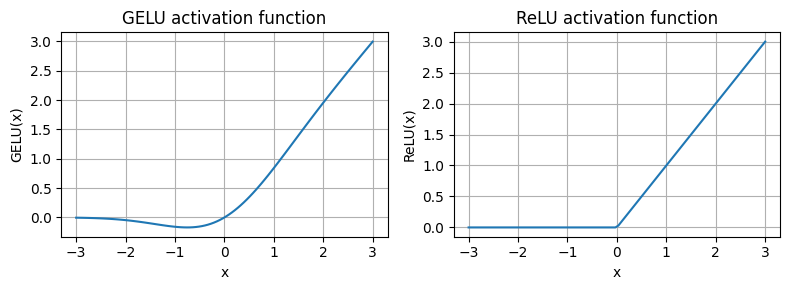

In [14]:
import matplotlib.pyplot as plt

gelu, relu = nn.GELU(), nn.ReLU()

# 샘플 데이터
x = torch.linspace(-3, 3, 100)
y_relu = relu(x)
y_gelu = gelu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

5. 피드 포워드 네트워크(Feed Forward Network, FFN) 구현
    - 트랜스포머 아키텍처에서 각 트랜스포머 블록 내에 존재하는 완전 연결 신경망
    - 각 토큰의 표현을 독립적으로 변환하는 역할을 한다.
    - 일반적으로 두 개의 선형 변환과 그 사이에 비선형 활성화 함수(GELU 등)를 포함한다.
    - 입력 차원을 확장한 후 다시 원래 차원으로 축소하는 구조를 가진다.
    - 이는 모델이 더 복잡한 패턴을 학습할 수 있도록 돕는다.
    - 피드 포워드 네트워크는 트랜스포머 모델의 중요한 구성 요소로, 각 토큰의 표현을 더욱 풍부하게 만들어준다.
    - 입력 차원과 출력 차원이 동일하기 때문에 여러 층을 쌓을 수 있다.

6. 2개의 Liner 층과 하나의 GELU 활성화 함수로 구성된 피드 포워드 네트워크 구현
    - 첫 번째 Linear 층은 입력 차원을 확장하고, 두 번째 Linear 층은 다시 원래 차원으로 축소한다.
    - GELU 활성화 함수는 두 Linear 층 사이에 적용되어 비선형성을 추가한다.
    - 이 구조는 모델이 더 복잡한 패턴을 학습할 수 있도록 돕는다.
    - 피드 포워드 네트워크는 트랜스포머 블록 내에서 각 토큰의 표현을 독립적으로 변환하는 역할을 한다.

        ![피드 포워드 네트워크](image/04-03-ff2.png)    

        ![피드 포워드 네트워크](image/04-03-ff4.png)  

In [15]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], cfg["emb_dim"] * 4), # 입력 차원을 4배로 확장
            nn.GELU(), # GELU 활성화 함수
            nn.Linear(cfg["emb_dim"] * 4, cfg["emb_dim"]) # 다시 원래 차원으로 축소
        )
        
    def forward(self, x):
        return self.layers(x)

In [16]:
ffn = FeedForward(GPT_CONFIG_124M) # 피드 포워드 네트워크 초기화
x = torch.randn(2, 3, 768) # (배치 크기, 시퀀스 길이, 임베딩 차원)
out = ffn(x) # 더미 입력을 피드 포워드 네트워크에 주입하여 출력 계산
print("출력 크기:", out.shape) # (배치 크기, 시퀀스 길이, 임베딩 차원)
print("출력 예시:", out) # 출력 예시

출력 크기: torch.Size([2, 3, 768])
출력 예시: tensor([[[-0.37, -0.22,  0.20,  ..., -0.25,  0.05,  0.24],
         [ 0.01,  0.06,  0.40,  ...,  0.16, -0.04, -0.12],
         [ 0.16, -0.16, -0.08,  ..., -0.30,  0.24, -0.17]],

        [[ 0.29,  0.08,  0.10,  ..., -0.26, -0.05, -0.23],
         [-0.09,  0.23,  0.06,  ..., -0.21,  0.01, -0.24],
         [ 0.25, -0.00, -0.28,  ..., -0.07, -0.04,  0.04]]],
       grad_fn=<ViewBackward0>)


## Chapter 4 숏컷 연결 추가하기 <a class="anchor" id="chapter4"></a>
1. 숏컷 연결(Shortcut Connection) 또는 잔차 연결(Residual Connection)은 심층 신경망에서 자주 사용되는 기법으로, 층을 건너뛰어 입력을 출력에 직접 더하는 방식이다.
    - 이는 그레이디언트 소실(vanishing gradient) 문제를 완화하고, 더 깊은 네트워크를 효과적으로 훈련할 수 있도록 돕는다.
        - 그레디언트 소실은 신경망이 깊어질수록 그레디언트가 점점 작아져서 초기 층들이 제대로 학습되지 않는 현상을 말한다.
    - 숏컷 연결은 ResNet과 같은 모델에서 처음 도입되었으며, 이후 트랜스포머 아키텍처에서도 널리 사용되고 있다.

2. 아래의 그림은 숏컷 연결이 그레이디언트가 1개 이상의 층을 건너뛰어 연결하는 방식을 보여준다.
    - 이러한 연결은 한 층의 출력을 이후 층의 출력에 더하여, 그레이디언트가 더 깊은 층까지 효과적으로 전달될 수 있도록 한다.
    - 이러한 연결을 스킵연결이라고 부릅니다.

        ![숏컷 연결](image/04-04-shortcut2.png)

In [17]:
import torch.nn as nn

# 숏컷 연결을 설명하기 위한 신경망
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        
        # 5개의 선형 레이어와 GELU 활성화 함수로 구성된 신경망
        self.layers = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), nn.GELU()),
                nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), nn.GELU()),
                nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), nn.GELU()),   
                nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), nn.GELU()),
                nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), nn.GELU())
            ]
        )
        
    def forward(self, x):
        for layer in self.layers:
           layer_out = layer(x)
           # 입력과 출력의 크기가 같고 숏컷 연결이 활성화된 경우
           if self.use_shortcut and x.shape == layer_out.shape:
               x = x + layer_out # 숏컷 연결
           else:
               x = layer_out
        return x

In [18]:
import torch

# 숏컷 연결이 없는 긴경망 초기화
layer_sizes = [3, 3, 3, 3, 3, 1] # 각 레이어의 크기 정의
sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123) # 재현성을 위해 시드 설정
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [19]:
# 모델 출력이 사용자가 지정한 값( 0 )에 얼마나 가까운지 계산하는 손실함수
#   - 손실 함수: 모델의 예측과 실제 값 간의 차이를 측정하는 함수
def print_gradients(model, x):
    output = model(x) # 모델에 입력 주입하여 출력 계산
    target = torch.tensor([[0.]]) # 목표 출력 정의
    
    loss = nn.MSELoss() # 평균 제곱 오차 손실 함수
    loss = loss(output, target) # 타깃과 출력의 가까운 정도를 기반으로 신실 계산

    # 파이토치가 모델 각 층에서 손실 그레이디언트를 계산한다.
    loss.backward() 
    
    # model.named_parameters(): 모델의 모든 파라미터 이름과 값을 반복
    #   - 각 층의 그레이디언트를 비교하기 쉽도록 절대값을 취한 후 평균을 계산
    for name, param in model.named_parameters():
        if 'weight' in name: # 가중치 파라미터에 대해서만 그래디언트 출력
            print(f"{name}의 평균 그레디언트는: {param.grad.abs().mean().item()}입니다.")

In [20]:
# 숏컷 연결 없는 모델 적용
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight의 평균 그레디언트는: 0.00020174120436422527입니다.
layers.1.0.weight의 평균 그레디언트는: 0.00012011769285891205입니다.
layers.2.0.weight의 평균 그레디언트는: 0.0007152436301112175입니다.
layers.3.0.weight의 평균 그레디언트는: 0.00139885104727입니다.
layers.4.0.weight의 평균 그레디언트는: 0.005049602594226599입니다.


In [21]:
# 숏컷 연결을 가진 모델 만들기
torch.manual_seed(123) # 재현성을 위해 시드 설정
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)

# 숏컷 연결 있는 모델 적용
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight의 평균 그레디언트는: 0.22186800837516785입니다.
layers.1.0.weight의 평균 그레디언트는: 0.20709273219108582입니다.
layers.2.0.weight의 평균 그레디언트는: 0.3292388319969177입니다.
layers.3.0.weight의 평균 그레디언트는: 0.2667772173881531입니다.
layers.4.0.weight의 평균 그레디언트는: 1.3268063068389893입니다.


## Chapter 5 에텐션과 선형 층을 트랜스포머 블록에 연결하기 <a class="anchor" id="chapter5"></a>
1. GPT-2 모델에서 트랜스포머 블록이 12번 반복된다.
    - 각 트랜스포머 블록은 멀티헤드 셀프 어텐션(Multi-Head Self-Attention) 메커니즘과 피드 포워드 네트워크(Feed Forward Network, FFN)로 구성된다.
    - 이 두 구성 요소는 층 정규화(Layer Normalization)와 숏컷 연결(Shortcut Connection)을 통해 연결된다.
    - 이러한 구조는 모델이 입력 시퀀스의 복잡한 패턴을 학습하고, 각 토큰 간의 관계를 효과적으로 캡처할 수 있도록 돕는다.

        ![트랜스포머 블록 연결](image/04-05-add.png)

In [22]:
# 깃허브에서 previous_chapters.py 파일을 다운로드합니다.
!wget https://bit.ly/43BW1j3 -O previous_chapters.py


--2025-10-15 17:11:09--  https://bit.ly/43BW1j3
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/previous_chapters.py [following]
--2025-10-15 17:11:09--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4199 (4.1K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]   4.10K  --.-KB/s    in 0s      

2025-10-15 17:11:09 (38.4 MB/s) - ‘previous_chapter

In [ ]:
from previous_chapters import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 멀티헤드 어텐션 레이어 초기화
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        
        # 피드 포워드 네트워크 초기화
        self.ft = FeedForward(cfg) 
        
        self.norm1 = LayerNorm(cfg["emb_dim"]) # 첫 번째 층 정규화 레이어
        self.norm2 = LayerNorm(cfg["emb_dim"]) # 두 번째 층 정규화 레이어
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"]) # 숏컷 연결을 위한 드롭아웃 레이어
        
    def forward(self, x):
        shortcut = x # 숏컷 연결을 위한 입력 저장
        # 첫 번째 층 정규화 적용
        #   - 멀티해드 어텐션 전 사전 층 정규화
        x = self.norm1(x) 
        x = self.att(x) # 멀티헤드 어텐션 적용
        x = self.drop_shortcut(x) # 드롭아웃 적용
        x = x + shortcut # 숏컷 연결
        
        shortcut = x # 숏컷 연결을 위한 입력 저장
        # 두 번째 층 정규화 적용
        #   - 피드 포워드 네트워크 전 사전 층 정규화
        x = self.norm2(x) 
        x = self.ft(x) # 피드 포워드 네트워크 적용
        x = self.drop_shortcut(x) # 드롭아웃 적용
        x = x + shortcut # 숏컷 연결
        return x

In [24]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # BPE 토크나이저에서 사용할 어휘사전 크기
    "context_length": 1024, # 문맥 길이 - 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 벡터의 차원 - 각 토큰을 768 차원 백터로 변환
    "n_heads": 12, # 멀티헤드 어텐션에서 사용할 헤드의 개수
    "n_layers": 12, # 트랜스포머 블록의 개수
    "dropout": 0.1, # 드롭아웃 비율 - 과대적합을 막기 위해 10%를 랜던하게 제외한다.
    "qkv_bias": False, # 쿼리, 키, 값 선형 변환에 바이어스 항을 사용할지 여부 - 훈련 시 False, 추론 시 True
}

In [25]:
torch.manual_seed(123) # 재현성을 위해 시드 설정
x = torch.randn(2, 4, 768) # (batch_size, num_tokens, emb_dim)
block = TransformerBlock(GPT_CONFIG_124M) # 트랜스포머 블록 
out = block(x) # 더미 입력을 트랜스포머 블록에 주입하여 출력 계산초기화
print("출력 크기:", out.shape) # (batch_size, num_tokens, emb_dim)

# 출력은 전체 입력 시퀸스의 정보를 담은 문맥 벡터
#   - 시퀸스의 물리적 차원은 유지되지만, 내용은 각 토큰이 시퀸스 전체의 문맥을 반영하도록 변환된다.
print("출력 예시:", out) # 출력 예시

출력 크기: torch.Size([2, 4, 768])
출력 예시: tensor([[[ 0.19,  0.12, -0.37,  ..., -0.33, -2.15,  0.49],
         [ 0.40,  0.33, -0.79,  ..., -0.25,  0.40, -0.29],
         [ 0.93,  0.52,  0.90,  ..., -1.20, -0.33, -1.29],
         [-0.03,  2.10, -2.29,  ...,  0.65, -1.47, -0.76]],

        [[ 0.52,  1.19, -1.12,  ..., -0.54,  0.38,  0.37],
         [-0.48, -1.23, -0.52,  ...,  0.34, -0.26,  0.25],
         [-1.42, -0.47, -0.59,  ..., -0.17, -1.00,  1.10],
         [-0.55, -1.16,  0.15,  ..., -0.04, -0.63,  0.19]]],
       grad_fn=<AddBackward0>)


## Chapter 6 GPT 모델 만들기 <a class="anchor" id="chapter6"></a>
1. DummyTransdormerBlockr과 DummyLayerNorm 클래스를 실제 TransformerBlock과 LayerNorm 클래스로 교체한다.
    - TransformerBlock 클래스는 멀티헤드 셀프 어텐션과 피드 포워드 네트워크를 포함하며, 층 정규화와 숏컷 연결을 통해 이들을 연결한다.
    - LayerNorm 클래스는 입력 텐서를 정규화하여 그레이디언트 소실 문제를 완화하고, 모델의 훈련을 안정화한다.
    - 이러한 교체를 통해 GPT 모델이 실제 트랜스포머 아키텍처를 구현하게 된다.

2. GPT 모델의 전체 구조는 다음과 같다.
    - 입력 토큰은 임베딩 층을 통해 고차원 벡터로 변환된다.
    - 위치 임베딩이 추가되어 토큰의 순서 정보를 제공한다.
    - 여러 개의 트랜스포머 블록이 순차적으로 연결되어 입력 시퀀스의 복잡한 패턴을 학습한다.
    - 최종 출력은 선형 층과 소프트맥스 함수를 통해 각 토큰에 대한 확률 분포로 변환된다.
    - 이 구조는 모델이 자연어 처리 작업에서 높은 성능을 발휘할 수 있도록 돕는다.

        ![GPT 모델 구조](image/04-06-struture.png)

In [ ]:
# GPT 모델 구조 구현
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # 크기 [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [31]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # BPE 토크나이저에서 사용할 어휘사전 크기
    "context_length": 1024, # 문맥 길이 - 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 벡터의 차원 - 각 토큰을 768 차원 백터로 변환
    "n_heads": 12, # 멀티헤드 어텐션에서 사용할 헤드의 개수
    "n_layers": 12, # 트랜스포머 블록의 개수
    "drop_rate": 0.1, # 드롭아웃 비율 - 과대적합을 막기 위해 10%를 랜던하게 제외한다.
    "qkv_bias": False, # 쿼리, 키, 값 선형 변환에 바이어스 항을 사용할지 여부 - 훈련 시 False, 추론 시 True
}

In [ ]:
torch.manual_seed(123) # 재현성을 위해 시드 설정
model = GPTModel(GPT_CONFIG_124M) # GPT 모델 초기화
out = model(batch) # 배치 입력을 모델에 주입하여 로짓 계산

# 텍스트 1, 텍스트 2의 토큰 아이디
print("입력 배치: ", batch)

# 4개의 토큰을 가진 2개의 입격 토큰을 전달했기 때문에 출력은 (2, 4, 50257) 크기의 텐서
#   - 2개의 행은 2개의 텍스트 샘플에 해당
#   - 각 텍스트 샘플은 4개의 토큰으로 구성된다.
#   - 각 토큰은 토크나이저의 어휘사전 크기에 해당하는 50,257차원의 벡터로 표현된다.
print("출력 크기:", out.shape) # (배치 크기, 시퀀스 길이, 어휘사전 크기)
print("출력 :", out) # 출력 예시

입력 배치:  tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
출력 크기: torch.Size([2, 4, 50257])
출력 : tensor([[[ 0.36,  0.42, -0.07,  ...,  0.35,  0.47, -0.28],
         [-0.18, -0.57, -0.95,  ...,  0.05,  0.52, -0.32],
         [ 0.71,  0.03,  0.11,  ...,  0.10, -0.43, -0.26],
         [-1.01,  0.34, -0.12,  ...,  0.72,  0.40,  0.05]],

        [[-0.26,  0.09,  0.03,  ...,  0.27,  0.45, -0.68],
         [ 0.12,  0.37, -0.21,  ...,  0.77,  0.27,  0.22],
         [ 1.06,  1.03, -0.28,  ...,  0.69,  0.32, -0.32],
         [-0.16,  0.39,  0.33,  ...,  1.26, -0.19,  0.04]]],
       grad_fn=<UnsafeViewBackward0>)


3. GTP-2는 가중치 묶기(weight tying) 기법을 사용하여 모델의 파라미터 수를 줄인다.
    - 가중치 묶기는 입력 임베딩 층과 출력 헤드 층에서 동일한 가중치 행렬을 공유하는 방법이다.
    - 이를 통해 모델의 메모리 사용량을 줄이고, 훈련 속도를 향상시킬 수 있다.
    - 또한, 가중치 묶기는 모델이 더 일반화된 표현을 학습하도록 돕는다.

In [ ]:
total_params = sum(p.numel() for p in model.parameters())

print(f"모델의 총 파라미터 수: {total_params}")

모델의 총 파라미터 수: 163009536


In [45]:
print("토큰 임베딩 층 크기: ", model.tok_emb.weight.shape) # (어휘사전 크기, 임베딩 차원)
print("최종 출력 헤드 크기: ", model.out_head.weight.shape) # (임베딩 차원, 어휘사전 크기)

토큰 임베딩 층 크기:  torch.Size([50257, 768])
최종 출력 헤드 크기:  torch.Size([50257, 768])


4. 토크나이저의 어휘사전 크기에 해당하는 50,257에 해당하는 행이있다.
    - 가중치 묶기를 사용한다고 가정하고 GTP-2 모델에서 출력 층의 가중치를 제외힌다.

In [ ]:
# model.out_head.parameters(): 출력 헤드의 파라미터를 반환
# p.numel(): 파라미터 텐서 p의 원소 개수를 반환
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"가중치 묶기를 고려한 훈련 가능한 파라미터 개수: {total_params_gpt2:,}")

가중치 묶기를 고려한 훈련 가능한 파라미터 개수: 124,412,160


5. 경험상 토큰 임베딩과 출력 층을 따로 두는 것이 훈련과 모델 성능에 더 좋다.

In [ ]:
# 출력을 바이트 단위로 계산한다.
#   - 각 파라미터는 32비트(4바이트) 부동 소수점 숫자로 저장된다.
total_size_bytes = total_params * 4

total_size_mb = total_size_bytes / (1024 ** 2) # 바이트를 메가바이트로 변환

# 기교적 작은 LLM 모델이라도 저장 공간이 크다
print(f"모델의 총 크기: {total_size_mb:.2f} MB")

모델의 총 크기: 621.83 MB


In [51]:
# 연습문제 4.1: 피드 포워드 신경망과 어텐션 모듈에 있는 파라미터 수 계산

block = TransformerBlock(GPT_CONFIG_124M)
total_params = sum(p.numel() for p in block.ft.parameters())
print(f"피드 포워드 모듈의 총 파라미터 수: {total_params:,}")

total_params = sum(p.numel() for p in block.att.parameters())
print(f"어텐션 모듈의 총 파라미터 수: {total_params:,}")

피드 포워드 모듈의 총 파라미터 수: 4,722,432
어텐션 모듈의 총 파라미터 수: 2,360,064


In [52]:
# 연습문제 4.2: 더 큰 GPT 모델 초기화하기
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}


def get_config(base_config, model_name="gpt2-small"):
    GPT_CONFIG = base_config.copy()

    if model_name == "gpt2-small":
        GPT_CONFIG["emb_dim"] = 768
        GPT_CONFIG["n_layers"] = 12
        GPT_CONFIG["n_heads"] = 12

    elif model_name == "gpt2-medium":
        GPT_CONFIG["emb_dim"] = 1024
        GPT_CONFIG["n_layers"] = 24
        GPT_CONFIG["n_heads"] = 16

    elif model_name == "gpt2-large":
        GPT_CONFIG["emb_dim"] = 1280
        GPT_CONFIG["n_layers"] = 36
        GPT_CONFIG["n_heads"] = 20

    elif model_name == "gpt2-xl":
        GPT_CONFIG["emb_dim"] = 1600
        GPT_CONFIG["n_layers"] = 48
        GPT_CONFIG["n_heads"] = 25

    else:
        raise ValueError(f"잘못된 모델 이름입니다 {model_name}")

    return GPT_CONFIG


def calculate_size(model):

    total_params = sum(p.numel() for p in model.parameters())
    print(f"전체 파라미터 수: {total_params:,}")

    total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
    print(f"가중치 묶기를 고려한 훈련 가능한 파라미터 수: {total_params_gpt2:,}")

    # 총 크기를 바이트 단위로 계산 (float32, 매개변수당 4바이트 가정)
    total_size_bytes = total_params * 4

    # 메가바이트로 변환
    total_size_mb = total_size_bytes / (1024 * 1024)

    print(f"모델의 총 크기: {total_size_mb:.2f} MB")


In [ ]:
for model_abbrev in ("small", "medium", "large", "xl"):
    model_name = f"gpt2-{model_abbrev}"
    CONFIG = get_config(GPT_CONFIG_124M, model_name=model_name)
    model = GPTModel(CONFIG)
    print(f"\n\n{model_name}:") # 모델 이름 출력
    calculate_size(model)